## **Project: Data Analytics for a Credit Score**

### Task 1

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

file_path = "train_biased.csv" 
df = pd.read_csv(file_path)
df.head()


,ID,Customer_ID,Month,Name,City,Street,Age,SSN,Occupation,Annual_Income,...,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Credit_Score
0,NaN,CUS_0xd40,NaN,Aaron Maashoh,Lonton,Oxford Street,NaN,821-00-0265,Manager,19114.12,...,7,11.27,4.0,_,NaN,26.822620,22 Years and 1 Months,No,80.41529543900253,3
1,0x1603,CUS_0xd40,February,Aaron Maashoh,Lonton,Oxford Street,23.0,821-00-0265,Manager,19114.12,...,NaN,11.27,4.0,NaN,809.98,31.944960,NaN,No,118.28022162236736,3
2,0x1604,CUS_0xd40,NaN,NaN,Lonton,Oxford Street,-500.0,821-00-0265,Manager,19114.12,...,7,NaN,4.0,Good,809.98,28.609352,NaN,No,81.699521264648,3
3,0x1605,CUS_0xd40,April,Aaron Maashoh,Lonton,Oxford Street,23.0,821-00-0265,Manager,19114.12,...,4,6.27,4.0,Good,809.98,NaN,22 Years and 4 Months,No,199.4580743910713,3
4,NaN,CUS_0xd40,May,Aaron Maashoh,Lonton,Oxford Street,23.0,821-00-0265,Manager,19114.12,...,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,41.420153086217326,3


### Task 2

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        90058 non-null   object 
 1   Customer_ID               90107 non-null   object 
 2   Month                     90062 non-null   object 
 3   Name                      81113 non-null   object 
 4   City                      90149 non-null   object 
 5   Street                    90080 non-null   object 
 6   Age                       85512 non-null   float64
 7   SSN                       89999 non-null   object 
 8   Occupation                90056 non-null   object 
 9   Annual_Income             89906 non-null   object 
 10  Monthly_Inhand_Salary     76405 non-null   float64
 11  Num_Bank_Accounts         90167 non-null   float64
 12  Num_Credit_Card           89938 non-null   float64
 13  Interest_Rate             90151 non-null   fl

In [10]:
df.duplicated().sum()
# no duplicates

0

In [11]:
df.isnull().sum()

ID                           9942
Customer_ID                  9893
Month                        9938
Name                        18887
City                         9851
Street                       9920
Age                         14488
SSN                         10001
Occupation                   9944
Annual_Income               10094
Monthly_Inhand_Salary       23595
Num_Bank_Accounts            9833
Num_Credit_Card             10062
Interest_Rate                9849
Num_of_Loan                 10191
Type_of_Loan                20312
Delay_from_due_date          9988
Num_of_Delayed_Payment      16218
Changed_Credit_Limit        10067
Num_Credit_Inquiries        11898
Credit_Mix                   9915
Outstanding_Debt             9963
Credit_Utilization_Ratio     9975
Credit_History_Age          18209
Payment_of_Min_Amount        9957
Amount_invested_monthly     14120
Credit_Score                    0
dtype: int64

Now, let's visualise the columns, starting with categorical variables.

### _Categorical Variables_

#### **Visualisations**

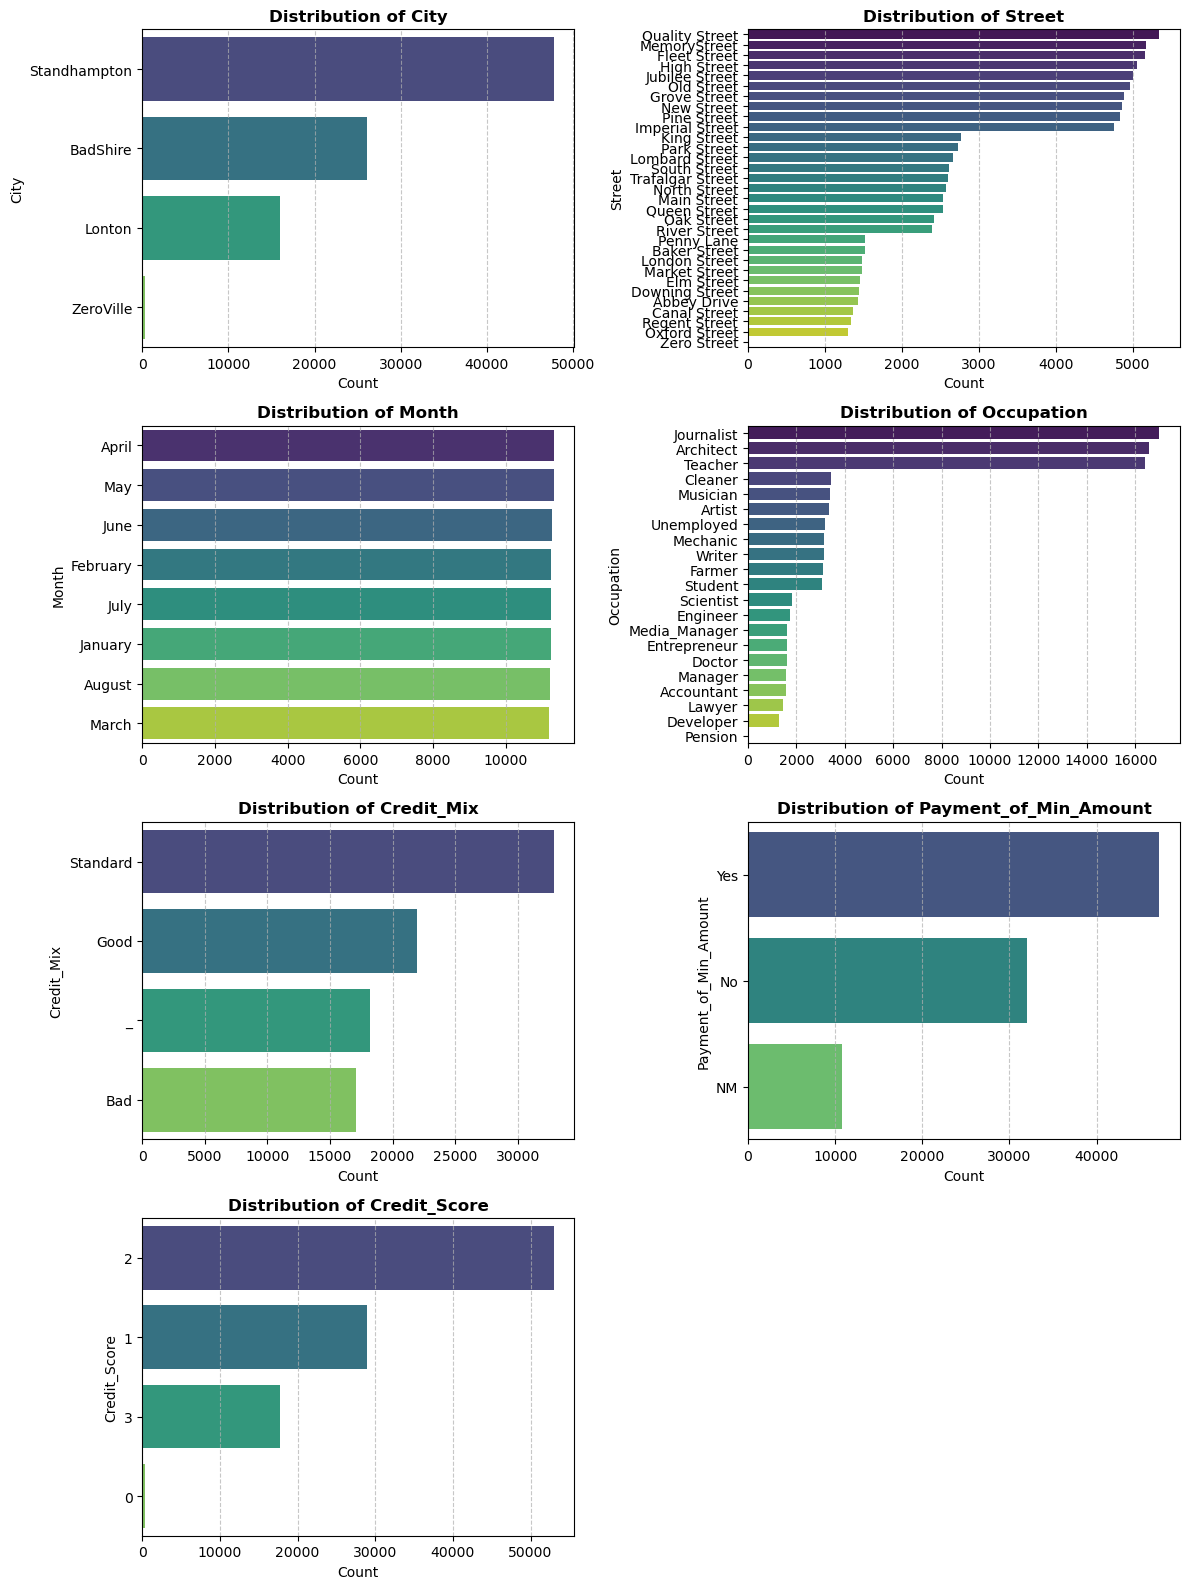

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_categorical_distribution(df, categorical_cols, cols_per_row=2):
    num_cols = len(categorical_cols)
    rows = math.ceil(num_cols / cols_per_row)  # Calculate number of rows
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(12, rows * 4))
    axes = axes.flatten()  # Flatten axes for easy indexing

    for i, col in enumerate(categorical_cols):
        count_data = df[col].value_counts()
        sns.countplot(y=df[col], order=count_data.index, ax=axes[i], palette="viridis")

        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel("Count", fontsize=10)
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].grid(axis='x', linestyle='--', alpha=0.7)

    # Remove empty subplots if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Example usage:
categorical1 = ["City", "Street", "Month", "Occupation", "Credit_Mix", "Payment_of_Min_Amount", "Credit_Score"]
plot_categorical_distribution(df, categorical1)


We drop column "ID" since we have multiple identification columns.

In [13]:
df = df.drop(columns=['ID'])

#### **Dealing with Type_of_Loan: String -> List**

We also noticed how "Type_of_Loan" is a str and hence, we had a problem visualising it. Let's convert each str entry to a tuple.

In [14]:
# converting type_of_loan to list
# deal with not spocified
def clean_loan_types(loan_str):
    if pd.isna(loan_str) or not isinstance(loan_str, str):
        return None  
    
    loan_str = loan_str.strip().replace("'", "")  
    loan_parts = loan_str.split(", ")  
    

    if len(loan_parts) > 1 and "and" in loan_parts[-1]:
        loan_parts[-1] = loan_parts[-1].replace("and ", "").strip()
    
    return tuple(loan_parts) 


df["Type_of_Loan"] = df["Type_of_Loan"].apply(clean_loan_types)
df["Type_of_Loan"].head()

0    (Auto Loan, Credit-Builder Loan, Personal Loan...
1    (Auto Loan, Credit-Builder Loan, Personal Loan...
2    (Auto Loan, Credit-Builder Loan, Personal Loan...
3    (Auto Loan, Credit-Builder Loan, Personal Loan...
4    (Auto Loan, Credit-Builder Loan, Personal Loan...
Name: Type_of_Loan, dtype: object

Now, we can visualise "Type_of_Loan"

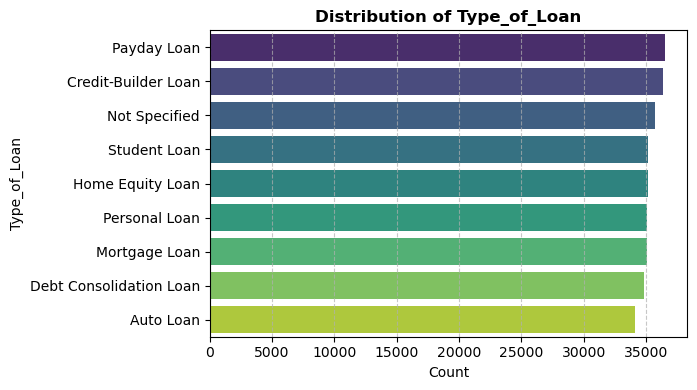

In [15]:

def plot_categorical_distribution2(df, categorical_cols, cols_per_row=2):
    num_cols = len(categorical_cols)
    rows = math.ceil(num_cols / cols_per_row)  
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(12, rows * 4))
    axes = axes.flatten() 

    for i, col in enumerate(categorical_cols):
        all_values = [item for sublist in df[col].dropna() for item in sublist]
        value_counts = Counter(all_values)

        value_counts_df = pd.DataFrame(value_counts.items(), columns=[col, "Count"]).sort_values(by="Count", ascending=False)

        sns.barplot(y=value_counts_df[col], x=value_counts_df["Count"], palette="viridis", ax=axes[i])

        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel("Count", fontsize=10)
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].grid(axis='x', linestyle='--', alpha=0.7)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_categorical_distribution2(df, categorical_cols=["Type_of_Loan"])



### **Dealing with Incorrect Values**

Let's fix some "Credit_Mix" and "Payment_of_Min_Amount" values. We replace "_" with None in Credit_mix and "NM" with None in Payment_of_Min_Amount, as it seems to stand for "Not Mentioned". It cannot be a typo for No as it occurs more than 10,000 times

In [16]:
# some preliminary cleaning
df["Credit_Mix"] = df["Credit_Mix"].replace("_", None)
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace("NM", None)


Now, let's look at "SSN" since visualising isn't relevant due to the multiple values in this column."Type_of_loan" isn't a list and hence, the visualisation is similarly messy as its plotting each individual combination.

In [17]:
# let's strip all colunns
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x).where(pd.notna(df), None)

categorical2 = ["SSN", "Type_of_Loan"]


for col in categorical2:
    print(f"Unique values in '{col}':")
    x=df[col].unique().tolist() # to better inspect each value
    print(x, "\n")

Unique values in 'SSN':
['821-00-0265', '#F%$D@*&8', None, '004-07-5839', '486-85-3974', '072-31-6145', '615-06-7821', '612-70-8987', '411-51-0676', '500-92-6408', '070-19-1622', '366-68-1681', '221-30-8554', '342-90-2649', '414-53-2918', '328-33-6328', '655-05-7666', '965-46-2491', '891-55-9364', '928-91-4452', '084-25-3745', '068-83-4394', '561-60-9294', '905-50-7912', '028-16-4402', '706-95-0150', '189-09-5267', '013-39-0742', '467-13-1148', '663-16-3845', '311-13-7309', '904-88-7361', '889-07-2357', '425-47-6723', '602-55-1355', '679-26-6464', '253-91-2822', '734-54-7098', '995-37-8920', '431-58-4893', '700-60-3660', '397-28-9675', '060-81-1328', '252-50-2326', '445-18-4420', '473-91-5845', '272-47-1135', '925-51-5335', '911-47-6879', '587-65-8904', '224-48-7837', '477-90-5881', '331-60-5414', '180-88-7800', '853-17-1579', '101-11-3105', '716-35-4628', '908-69-0212', '744-11-7914', '423-77-6457', '507-34-4117', '794-17-4490', '226-77-0587', '389-89-4542', '761-11-3016', '147-76-692

For "SSN", we see one invalid value #F%$D@*&8. Let's see if there are more.

In [18]:
import re

ssn_pattern = r"^\d{3}-\d{2}-\d{4}$"
invalid_ssns = df[~df["SSN"].astype(str).str.match(ssn_pattern, na=False)]

invalid_ssns['SSN'].head()

7     #F%$D@*&8
8          None
17         None
24         None
26         None
Name: SSN, dtype: object

Turns out we have only one invalid entry, let's replace it with None.

In [19]:
df["SSN"] = df["SSN"].replace("#F%$D@*&8", None) # replace one weird code with None


In [20]:
x=df["SSN"].unique().tolist() # to better inspect each value
print(x)

['821-00-0265', None, '004-07-5839', '486-85-3974', '072-31-6145', '615-06-7821', '612-70-8987', '411-51-0676', '500-92-6408', '070-19-1622', '366-68-1681', '221-30-8554', '342-90-2649', '414-53-2918', '328-33-6328', '655-05-7666', '965-46-2491', '891-55-9364', '928-91-4452', '084-25-3745', '068-83-4394', '561-60-9294', '905-50-7912', '028-16-4402', '706-95-0150', '189-09-5267', '013-39-0742', '467-13-1148', '663-16-3845', '311-13-7309', '904-88-7361', '889-07-2357', '425-47-6723', '602-55-1355', '679-26-6464', '253-91-2822', '734-54-7098', '995-37-8920', '431-58-4893', '700-60-3660', '397-28-9675', '060-81-1328', '252-50-2326', '445-18-4420', '473-91-5845', '272-47-1135', '925-51-5335', '911-47-6879', '587-65-8904', '224-48-7837', '477-90-5881', '331-60-5414', '180-88-7800', '853-17-1579', '101-11-3105', '716-35-4628', '908-69-0212', '744-11-7914', '423-77-6457', '507-34-4117', '794-17-4490', '226-77-0587', '389-89-4542', '761-11-3016', '147-76-6929', '878-90-6321', '616-36-8188', '49

### **Dealing with Incnsistent Values**

Let's deal with the inconsistent data as there are multiple instances of this as we previously defined.

In [21]:
charlie_df = df[df["Name"] == "Charlieg"][["Name", "Credit_Mix"]]
display(charlie_df)

,Name,Credit_Mix
28712,Charlieg,Good
28713,Charlieg,Good
28715,Charlieg,None
28717,Charlieg,None
28718,Charlieg,None
28719,Charlieg,Good


In [22]:
consistent_columns = [
    "Customer_ID", 
    "Name", 
    "Credit_Mix",
    "SSN", 
    "Type_of_Loan"
]
# Age is also consistent but let's deal with it later as it a continuous variable

Now, we profile each Customer_ID with their mode and replace any inconsistent value with the respective mode.

In [23]:
def enforce_profile_consistency(df, group_by_col, cols_to_fix):
    for col in cols_to_fix:
        mode_values = df.groupby(group_by_col)[col].agg(lambda x: x.mode().dropna().iloc[0] if not x.mode().dropna().empty else x.dropna().iloc[0] if not x.dropna().empty else None)
        df[col] = df[col].fillna(df[group_by_col].map(mode_values)) 
        df[col] = df[group_by_col].map(mode_values)  
    return df
df = enforce_profile_consistency(df, group_by_col="Customer_ID", cols_to_fix=consistent_columns)


In [24]:
charlie_df = df[df["Name"] == "Charlieg"][["Name", "Credit_Mix"]]
display(charlie_df)

,Name,Credit_Mix
28712,Charlieg,Good
28713,Charlieg,Good
28714,Charlieg,Good
28715,Charlieg,Good
28716,Charlieg,Good
28717,Charlieg,Good
28718,Charlieg,Good
28719,Charlieg,Good


### **Dealing with Null Values**

Now, that we have replaced the inconsistent data with the mode. Let's go ahead and deal with Null values (in the consistent columns). Firstly, let's look at month.

In [25]:
df['Month'].head(20)

0         None
1     February
2         None
3        April
4          May
5         June
6         July
7       August
8      January
9     February
10       March
11       April
12        None
13        June
14        July
15        None
16     January
17    February
18       March
19       April
Name: Month, dtype: object

We see a simple chronological pattern. Each entry takes place once per month (from January-August). Thus, we use this information correct the Nulls.

In [26]:

month_cycle = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']

def fill_month_chronologically(df):

    if pd.isna(df.at[0, 'Month']):
        df.at[0, 'Month'] = 'January' # Manually dealing with first missing month.

    for i in range(1,len(df)):
        if pd.isna(df.at[i, 'Month']): 
            if i > 0 and df.at[i - 1, 'Month'] in month_cycle: 
                last_month = df.at[i - 1, 'Month']
                next_month = month_cycle[(month_cycle.index(last_month) + 1) % len(month_cycle)]
                df.at[i, 'Month'] = next_month

    return df

df = fill_month_chronologically(df)


In [27]:
df['Month'].isnull().sum()

0

Next method we use is forward/backward filling since entries are grouped by each customer. For example, if:
- row 1:"Name" = Charlie
- row 2:"Name" = None
- row 3:"Name" = Charlie

Then the name in row 2 is likely to be Charlie as well. 

Here, to deal with the first and last row per customer, we use the month column. (Backward-fill if month = January, Forward-fill if month = August)

It is important to note that we don't just do this for consistent columns, but also for certain other columns for the following reasons:

| Feature                | Reason                                                                                           |
|------------------------|--------------------------------------------------------------------------------------------------|
| Street                 | Often same over time per person, missing values can be forward/backward filled from nearby rows (if time-indexed or sorted by ID). |
| City                   | Same logic as Street; doesn't change often, missing entries can be inferred from adjacent ones.  |
| Occupation             | Usually stable over short time periods. Forward/backward fill can carry forward known values.    |
| Payment_of_Min_Amount  | Categorical and repetitive in behavior. Forward fill is good for customer transaction history.   |


In [28]:
other_categ_fbf = ['Street', 'City', 'Occupation', 'Payment_of_Min_Amount']
cols_to_fill= consistent_columns+other_categ_fbf

In [29]:
def forward_backward_fill(df, cols_to_fill):

    if df['Month'].iloc[0] == "January":  
        df[cols_to_fill] = df[cols_to_fill].bfill()
    
    elif df['Month'].iloc[-1] == "August":  
        df[cols_to_fill] = df[cols_to_fill].ffill()
    else:
        df[cols_to_fill] = df[cols_to_fill].ffill().bfill()

    return df

df = forward_backward_fill(df, cols_to_fill)

In [30]:
df[categorical1+categorical2].isnull().sum()

City                     0
Street                   0
Month                    0
Occupation               0
Credit_Mix               0
Payment_of_Min_Amount    0
Credit_Score             0
SSN                      0
Type_of_Loan             0
dtype: int64

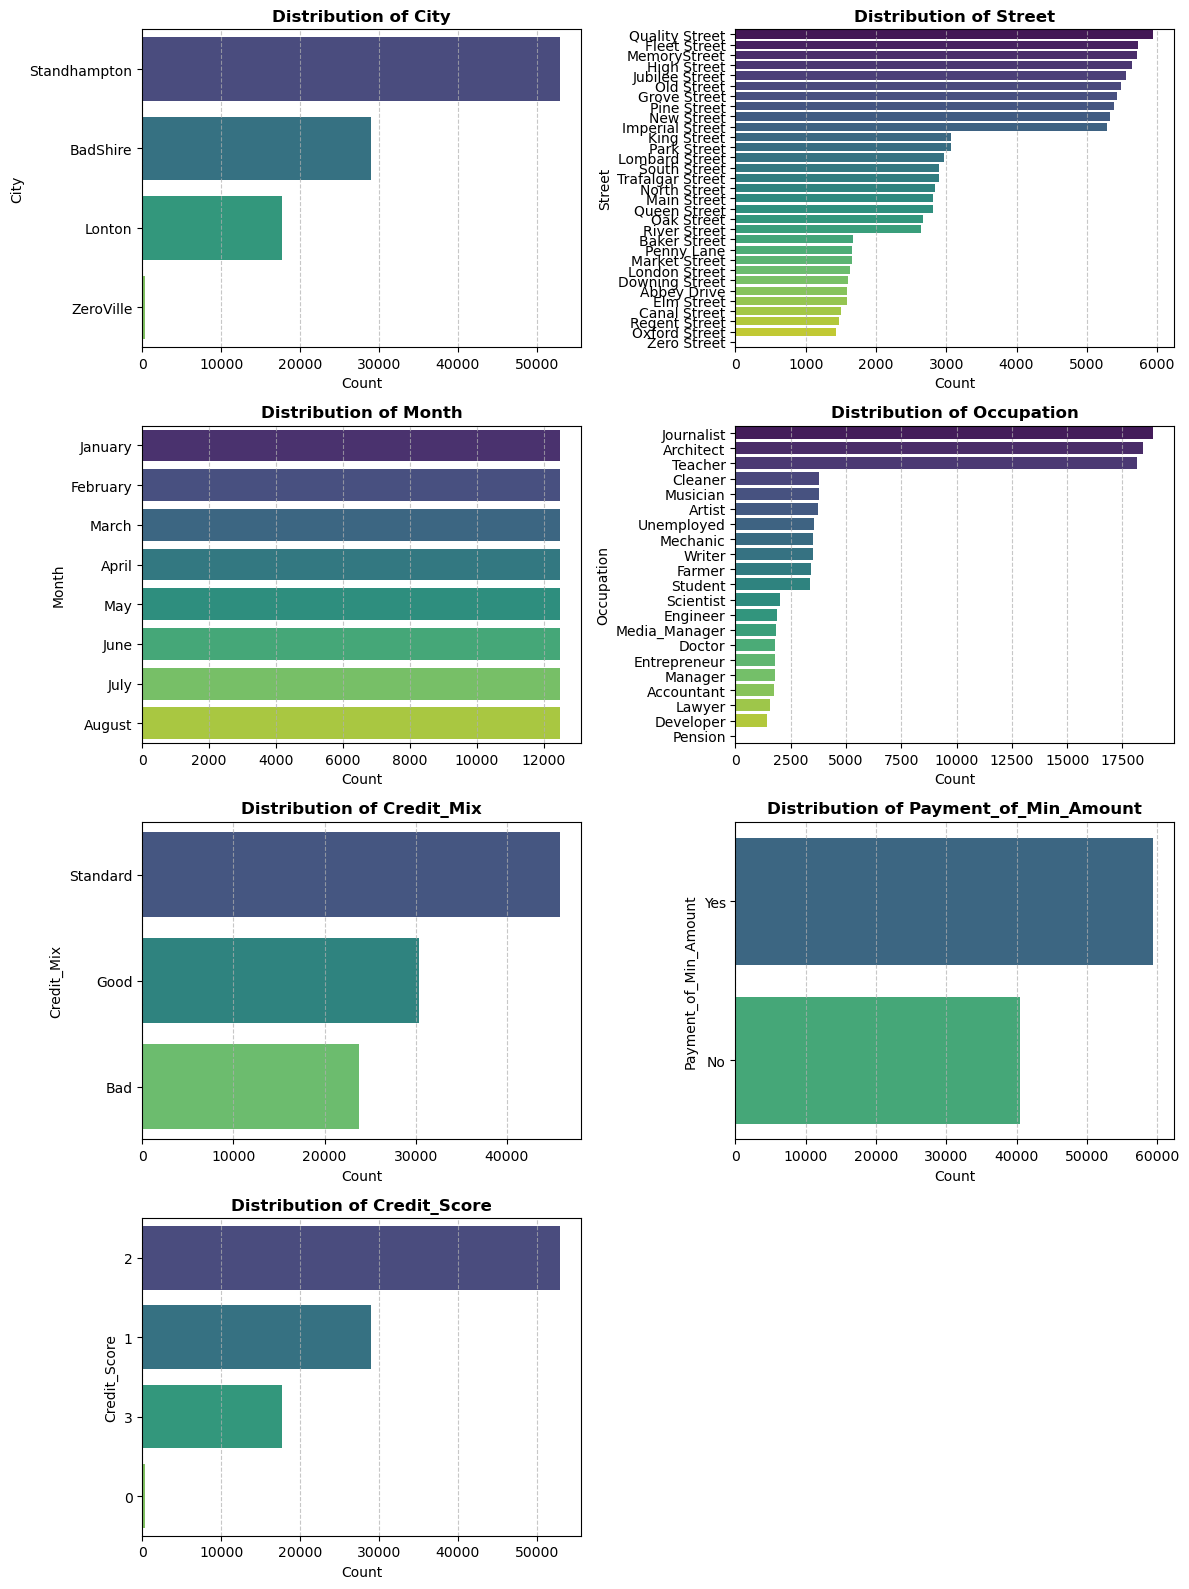

In [31]:
plot_categorical_distribution(df, categorical1)

## _Continuous_

### **Visulaisations**

Let's move on and plot continuous variables as a distribution.

In [32]:
categorical = categorical1+["SSN", "Type_of_Loan"]
continuous_cols = [col for col in df.columns if col not in categorical and df[col].dtype in ['int64', 'float64']]

for i in continuous_cols: 
    print(i)


Age
Monthly_Inhand_Salary
Num_Bank_Accounts
Num_Credit_Card
Interest_Rate
Delay_from_due_date
Num_Credit_Inquiries
Credit_Utilization_Ratio


These are not all the columns.

In [33]:
other_columns = [col for col in df.columns if col not in continuous_cols and col not in categorical]
for i in other_columns:
    print(i)


Customer_ID
Name
Annual_Income
Num_of_Loan
Num_of_Delayed_Payment
Changed_Credit_Limit
Outstanding_Debt
Credit_History_Age
Amount_invested_monthly


We don't need ID, Customer_ID and Name, but we do need the others. Let's look at each of them manually to see what's wrong.

Annual_Income has str values in the format "19114.12_". Let's convert these to float. Num_of_Loan, Outstanding_Debt & Num_of_Delayed_Payment has the same problem.

In [34]:
df["Annual_Income"] = df["Annual_Income"].str.rstrip("_").astype(float)
df["Num_of_Loan"] = df["Num_of_Loan"].str.rstrip("_").astype(float)
df["Num_of_Delayed_Payment"] = df["Num_of_Delayed_Payment"].str.rstrip("_").astype(float)
df["Outstanding_Debt"] = df["Outstanding_Debt"].str.rstrip("_").astype(float)


Let's now simply change Changed_Credit_Limit to numeric.

In [35]:
df["Changed_Credit_Limit"] = pd.to_numeric(df["Changed_Credit_Limit"], errors='coerce')

In [36]:
df["Changed_Credit_Limit"].isnull().sum()

11942

Credit_History_Age is this format - "22 Years and 1 Months", let's change this to numerical.

In [37]:
import re
def convert_credit_history_to_months(value):
    if isinstance(value, (int, float)):  # keep float values unchanged
        return value
    match = re.match(r"(\d+) Years? and (\d+) Months?", str(value))
    if match:
        years, months = map(int, match.groups())
        return float(years * 12 + months)
    return None 

df["Credit_History_Age"] = df["Credit_History_Age"].apply(convert_credit_history_to_months)


Lastly, Amount_invested_monthly has values like "__ 10000 __" that need to be fixed.

In [38]:
df["Amount_invested_monthly"] = df["Amount_invested_monthly"].str.strip("_").astype(float)

Now, we proceed with their visualisation of the distribution using __Box plots__. We also display the outliers (without visualising them as there exist multiple outliers, resulting in uninterpretable graphs!)

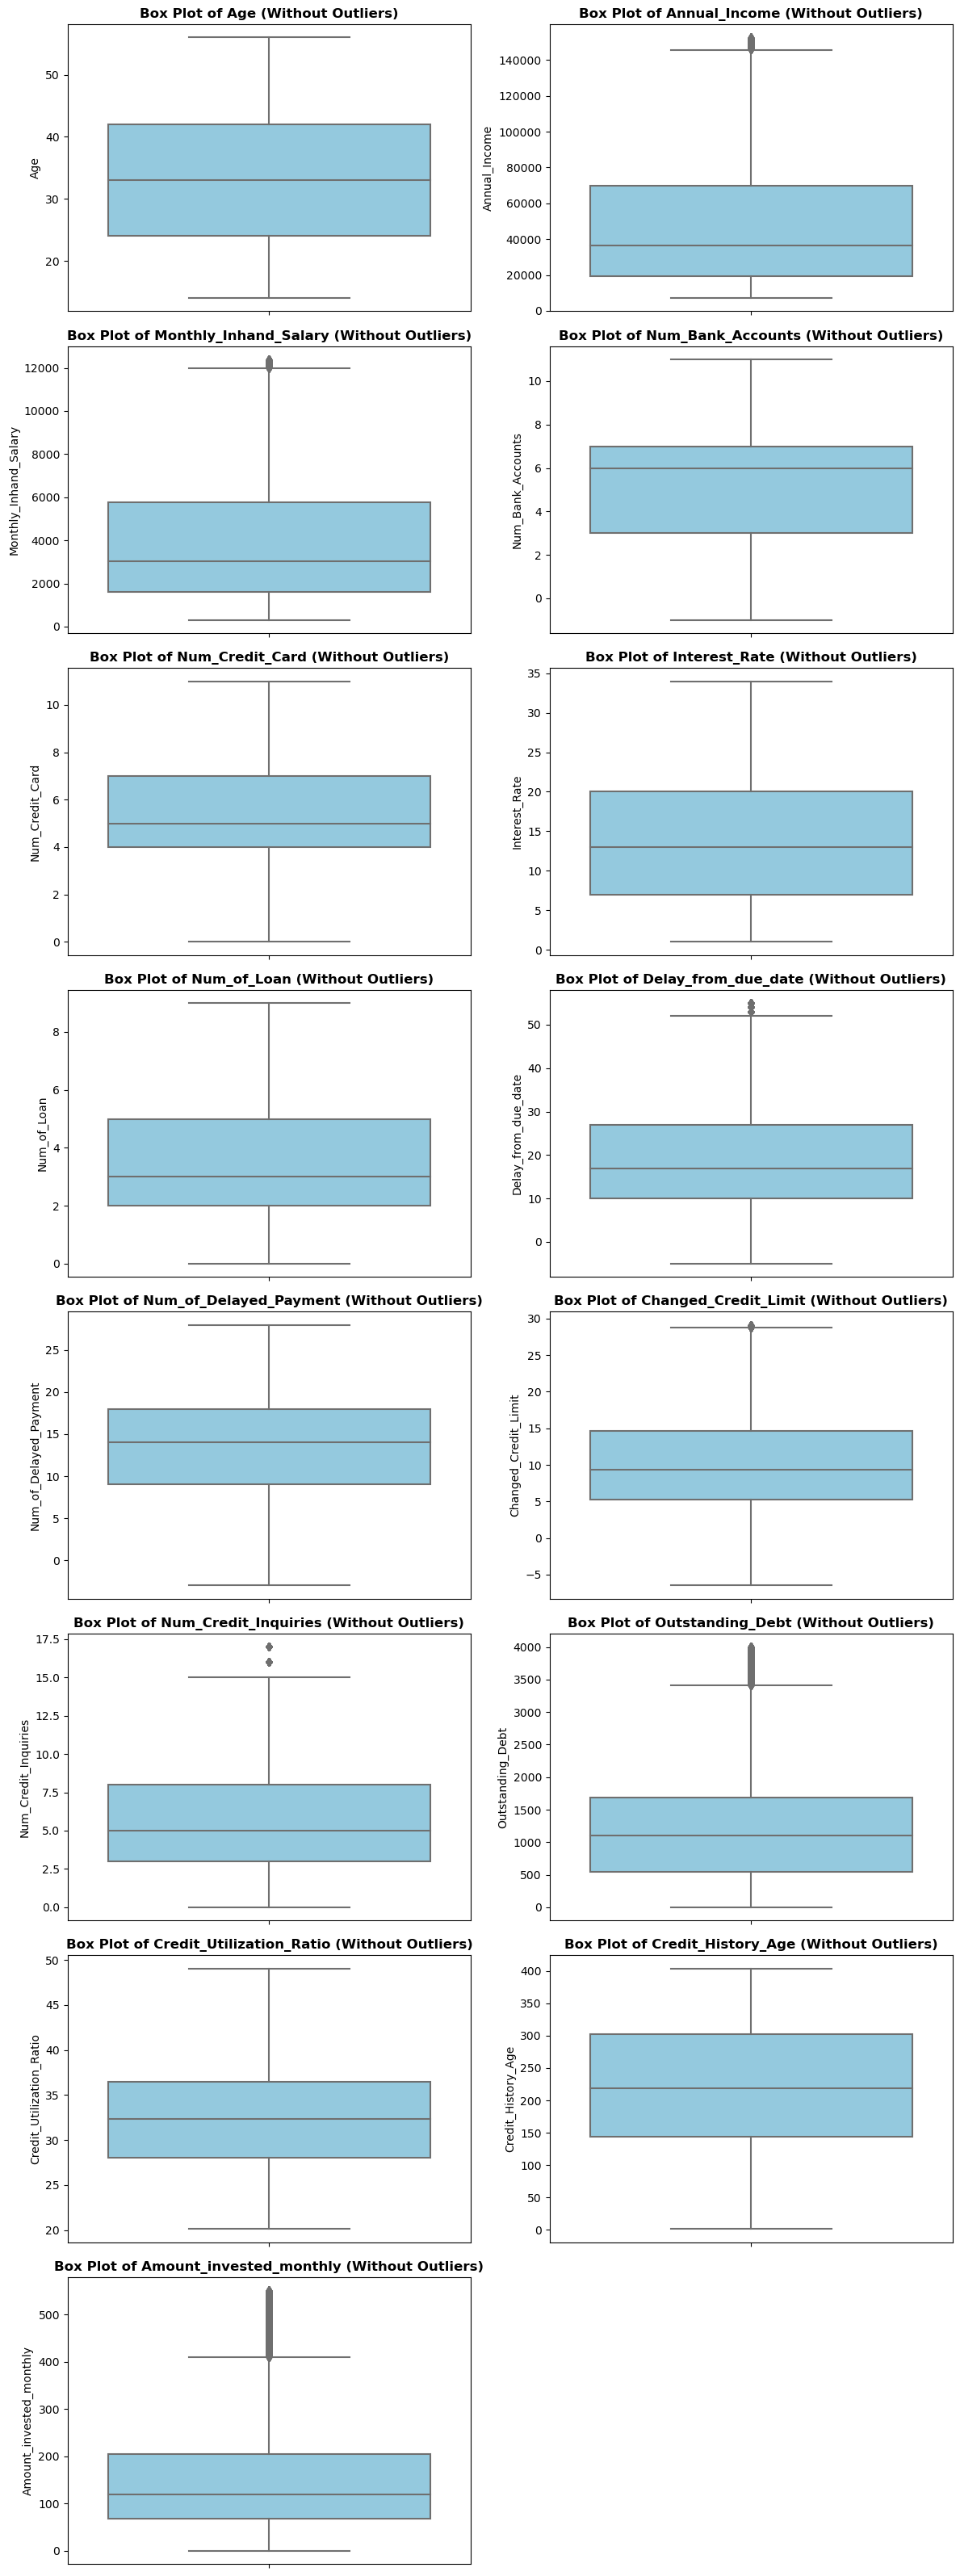


Outliers in Age:


2      -500.0
56     7580.0
113    -500.0
122     181.0
219     995.0
243    5079.0
288    6409.0
289    -500.0
301    7080.0
328     849.0
Name: Age, dtype: float64


Outliers in Annual_Income:


54     10909427.0
231     6515990.0
245      586359.0
361    18334118.0
368    19717385.0
379     2709655.0
564    19257912.0
602    22335783.0
617    16367214.0
862     8908998.0
Name: Annual_Income, dtype: float64


Outliers in Monthly_Inhand_Salary:


...

417    4071.62
418    4071.62
419    4071.62
420    4071.62
421    4071.62
422    4071.62
423    4071.62
480    4834.59
481    4834.59
482    4834.59
Name: Outstanding_Debt, dtype: float64


Outliers in Credit_Utilization_Ratio:


9382     50.000000
17029    49.522324
62954    49.254983
68000    49.564519
Name: Credit_Utilization_Ratio, dtype: float64


Outliers in Amount_invested_monthly:


18    10000.000000
19      825.216270
23    10000.000000
28    10000.000000
43      618.202391
49      698.873271
54      930.391898
55      870.522382
68      649.809364
93      686.126217
Name: Amount_invested_monthly, dtype: float64

In [39]:

def plot_grouped_boxplots(df, continuous_cols, cols_per_row=2):
    num_cols = len(continuous_cols)
    rows = math.ceil(num_cols / cols_per_row)  

    fig, axes = plt.subplots(rows, cols_per_row, figsize=(12, rows * 4))
    axes = axes.flatten() 

    outlier_info = {}  

    for i, col in enumerate(continuous_cols):
        # Calculate IQR and outliers
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_filtered = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        if not outliers.empty:
            outlier_info[col] = outliers
        
        sns.boxplot(y=df_filtered[col], color="skyblue", ax=axes[i])
        axes[i].set_title(f'Box Plot of {col} (Without Outliers)', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(col, fontsize=10)

    # Remove empty subplots if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    # Print outlier information
    for col, outliers in outlier_info.items():
        print(f"\nOutliers in {col}:")
        display(outliers[col].head(10))

# Example usage:
continuous_cols = [col for col in df.columns if col not in categorical and df[col].dtype in ['int64', 'float64']]
plot_grouped_boxplots(df, continuous_cols)



#### __Dealing with Incorrect Values__

We see that in column "Age", most values are outside the standard age range of 18-100, assuming only adults are present in the dataset.

In [40]:
df["Age"] = df["Age"].apply(lambda x: x if 18 <= x <= 100 else None)

For Num_Bank_Accounts, we also have -1 in the distribution (very often as this wasn't an outlier). We don't change this to None but rather just change it to 1 as it isn't a value too extreme to interpret.

In [41]:
df['Num_Bank_Accounts'] = df['Num_Bank_Accounts'].replace(-1, 1)

Further, we put a similar boundary on Delay_from_due_date where negative values are converted to 0, since negative delay is equivalent of no delay.

However, these could also be positive values that are misentered as negative. Let's quickly verify this before we proceed.

In [42]:
'''negative_delay_df = df[df['Delay_from_due_date'] < 0]
avg_credit_score_per_customer = negative_delay_df.groupby('Customer_ID')['Credit_Score'].mean().reset_index()
avg_credit_score_per_customer.mean()'''
negative_delay_df = df[df['Delay_from_due_date'] < 0]
avg_credit_score_per_customer = negative_delay_df.groupby('Customer_ID')['Credit_Score'].mean().reset_index()
average_credit_score = avg_credit_score_per_customer['Credit_Score'].mean()
print(average_credit_score)

2.456486042692939


Thus, we observe the mean Credit_Score for customers that have negative delays and notice that it is ~2.5 (high). Hence, our assumption is true as no delay is likely to contribute to higher Credit_Score.

In [43]:
df['Delay_from_due_date'] = df['Delay_from_due_date'].apply(lambda x: max(x, 0))

We check similarly for 'Num_of_Delayed_Payment'.

In [44]:
negative_delay_df = df[df['Num_of_Delayed_Payment'] < 0]
avg_credit_score_per_customer = negative_delay_df.groupby('Customer_ID')['Credit_Score'].mean().reset_index()
average_credit_score = avg_credit_score_per_customer['Credit_Score'].mean()
print(average_credit_score)

2.2916666666666665


The average here is also greater than 2. Therefore, it is similarly suitable to convert negative values to 0. 

In [45]:
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].apply(lambda x: max(x, 0))

We also notice that not all entries follow the following formula: Annual_Income = Monthly_Inhand_Salary x 12.

In [46]:
mismatched_rows = df[
    (pd.notnull(df["Monthly_Inhand_Salary"])) &
    (pd.notnull(df["Annual_Income"])) &
    (df["Annual_Income"] != df["Monthly_Inhand_Salary"] * 12)
]

print(f"Number of mismatched rows: {len(mismatched_rows)}/{len(df)}")


Number of mismatched rows: 68569/100000


Thus, we correct this, substituting nulls where the monthly_inhand_salary is missing.

In [47]:
df["Annual_Income"] = df["Monthly_Inhand_Salary"].apply(
    lambda x: x * 12 if pd.notnull(x) else None
)

Lastly, num_of_loan is simply the count of the type_of_loan column.

In [48]:
df["Num_of_Loan"] = len(df["Type_of_Loan"]) # we can do this as we already converted the string column to a list

#### **Dealing with Outliers**

Nevertheless, for all columns, we substitue the outliers with None for two reasons:
1. For all outliers removed, we see that the Box-Plot becomes rather concise, validating the effectiveness of the method in removing extreme values. 
2. We do not delete the rows, at least for now, which means there isn't major data loss.

In [49]:
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = None

#### **Dealing with Nulls**

First, let's look at some obvious patterns.

In [50]:
aaron_df = df[df["Name"] == "Aaron Maashoh"][["Name", "Credit_History_Age"]]
aaron_df

,Name,Credit_History_Age
0,Aaron Maashoh,265.0
1,Aaron Maashoh,NaN
2,Aaron Maashoh,NaN
3,Aaron Maashoh,268.0
4,Aaron Maashoh,269.0
5,Aaron Maashoh,270.0
6,Aaron Maashoh,271.0
7,Aaron Maashoh,NaN


We see that as we progress month-wise through each row, the Credit_History_Age increase (by 1). Thus, we can use this in filling the null vales.

In [51]:
def fill_credit_history(group):
    group = group.reset_index(drop=True)
    
    for i in range(len(group)):
        if pd.isna(group.loc[i, 'Credit_History_Age']):
            # January case: Use next month - 1
            if group.loc[i, 'Month'] == 'January' and i + 1 < len(group) and not pd.isna(group.loc[i + 1, 'Credit_History_Age']):
                group.loc[i, 'Credit_History_Age'] = group.loc[i + 1, 'Credit_History_Age'] - 1
            
            # Other months: Use previous month + 1
            elif i > 0 and not pd.isna(group.loc[i - 1, 'Credit_History_Age']):
                group.loc[i, 'Credit_History_Age'] = group.loc[i - 1, 'Credit_History_Age'] + 1
    
    return group

df = df.groupby('Customer_ID', group_keys=False).apply(fill_credit_history)

In [52]:
aaron_df = df[df["Name"] == "Aaron Maashoh"][["Name", "Credit_History_Age"]]
aaron_df

,Name,Credit_History_Age
0,Aaron Maashoh,265.0
1,Aaron Maashoh,266.0
2,Aaron Maashoh,267.0
3,Aaron Maashoh,268.0
4,Aaron Maashoh,269.0
5,Aaron Maashoh,270.0
6,Aaron Maashoh,271.0
7,Aaron Maashoh,272.0


Num_of_Loan is simple len(Type_of_Loan), since we converted it into a list earlier.

In [53]:
df["Num_of_Loan"] = df["Type_of_Loan"].apply(lambda x: len(x) if isinstance(x, tuple) else 0)


Let's use the same method we used for forward-backward filling to fill in continouse values that stay consistent, at least in the short-term.

In [54]:
charlie_df = df[df["Name"] == "Charlieg"][["Name", "Num_Credit_Card"]]
display(charlie_df)

,Name,Num_Credit_Card
0,Charlieg,5.0
1,Charlieg,NaN
2,Charlieg,5.0
3,Charlieg,5.0
4,Charlieg,NaN
5,Charlieg,5.0
6,Charlieg,5.0
7,Charlieg,5.0


In [55]:
consistent_columns_cont=[
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Outstanding_Debt",
    "Num_of_Loan",
]

In [56]:
df = forward_backward_fill(df, cols_to_fill=consistent_columns_cont)

In [57]:
charlie_df = df[df["Name"] == "Charlieg" ][["Name", "Num_Credit_Card"]]
display(charlie_df)

,Name,Num_Credit_Card
0,Charlieg,5.0
1,Charlieg,5.0
2,Charlieg,5.0
3,Charlieg,5.0
4,Charlieg,5.0
5,Charlieg,5.0
6,Charlieg,5.0
7,Charlieg,5.0


Next, for these columns:
    'Credit_History_Age', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Amount_invested_monthly'


We use the __KNN Imputer__ from scikit-learn models. This is a machine learning-based imputation technique that estimates missing values by finding the k-nearest neighbors based on other features. It fills in missing data by averaging the values from similar instances, effectively capturing the underlying structure of the dataset without making strong assumptions about data distribution.

In [58]:
ali_df = df[df["Customer_ID"] == "CUS_0x1000"][["Name","Month", "Delay_from_due_date"]]
# we use Customer_ID as there are 2 cutomers with the name Alison Barff
display(ali_df)

,Name,Month,Delay_from_due_date
0,Alistair Barrf,January,NaN
1,Alistair Barrf,February,NaN
2,Alistair Barrf,March,NaN
3,Alistair Barrf,April,NaN
4,Alistair Barrf,May,NaN
5,Alistair Barrf,June,NaN
6,Alistair Barrf,July,NaN
7,Alistair Barrf,August,NaN


In [59]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

knn_features = [
    'Credit_History_Age', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Amount_invested_monthly'
]

# scale before KNN
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[knn_features]), columns=knn_features)

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df_scaled), columns=knn_features)

# inverse scale 
df[knn_features] = scaler.inverse_transform(df_imputed)

'''from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

cols = [
    'Credit_History_Age', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Amount_invested_monthly'
]


iter_imputer = IterativeImputer(estimator=BayesianRidge(), random_state=42)
df[cols] = iter_imputer.fit_transform(df[cols])'''

# we used another method but the accuracies were much lower

"from sklearn.experimental import enable_iterative_imputer \nfrom sklearn.impute import IterativeImputer\nfrom sklearn.linear_model import BayesianRidge\n\ncols = [\n    'Credit_History_Age', 'Delay_from_due_date',\n    'Num_of_Delayed_Payment', 'Changed_Credit_Limit',\n    'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Amount_invested_monthly'\n]\n\n\niter_imputer = IterativeImputer(estimator=BayesianRidge(), random_state=42)\ndf[cols] = iter_imputer.fit_transform(df[cols])"

In [60]:
ali_df = df[df["Customer_ID"] == "CUS_0x1000"][["Name","Month", "Delay_from_due_date"]] 
# we use Customer_ID as there are 2 cutomers with the name Alison Barff
display(ali_df)

,Name,Month,Delay_from_due_date
0,Alistair Barrf,January,33.4
1,Alistair Barrf,February,24.4
2,Alistair Barrf,March,27.6
3,Alistair Barrf,April,33.8
4,Alistair Barrf,May,38.6
5,Alistair Barrf,June,27.0
6,Alistair Barrf,July,30.0
7,Alistair Barrf,August,27.2


In [61]:
df.isnull().sum()

Customer_ID                 0
Month                       0
Name                        0
City                        0
Street                      0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               2
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Amount_invested_monthly     0
Credit_Score                0
dtype: int64

We notice that Interest_Rate and Num_Credit_Inquiries still has 2 and 1 missing values resepctively.

In [62]:
damo_df = df[df['Interest_Rate'].isnull()][["Name", "Interest_Rate"]]
display(damo_df)


,Name,Interest_Rate
6,Damouniq,NaN
7,Damouniq,NaN


Let's manually fix this.

In [63]:
damo_df = df[df['Name']=="Damouniq"][["Name", "Interest_Rate"]]
display(damo_df.tail(4))

,Name,Interest_Rate
4,Damouniq,13.0
5,Damouniq,13.0
6,Damouniq,NaN
7,Damouniq,NaN


In [64]:
df.fillna({'Interest_Rate': 13.0}, inplace=True)

In [65]:
damo_df = df[df['Name']=="Damouniq"][["Name", "Interest_Rate"]]
display(damo_df.tail(4))

,Name,Interest_Rate
4,Damouniq,13.0
5,Damouniq,13.0
6,Damouniq,13.0
7,Damouniq,13.0


In [66]:
df['Interest_Rate'].isnull().sum()

0

We now have a significantly cleaner dataset to work with!

Now, let's visualise our cleaned categorical data.

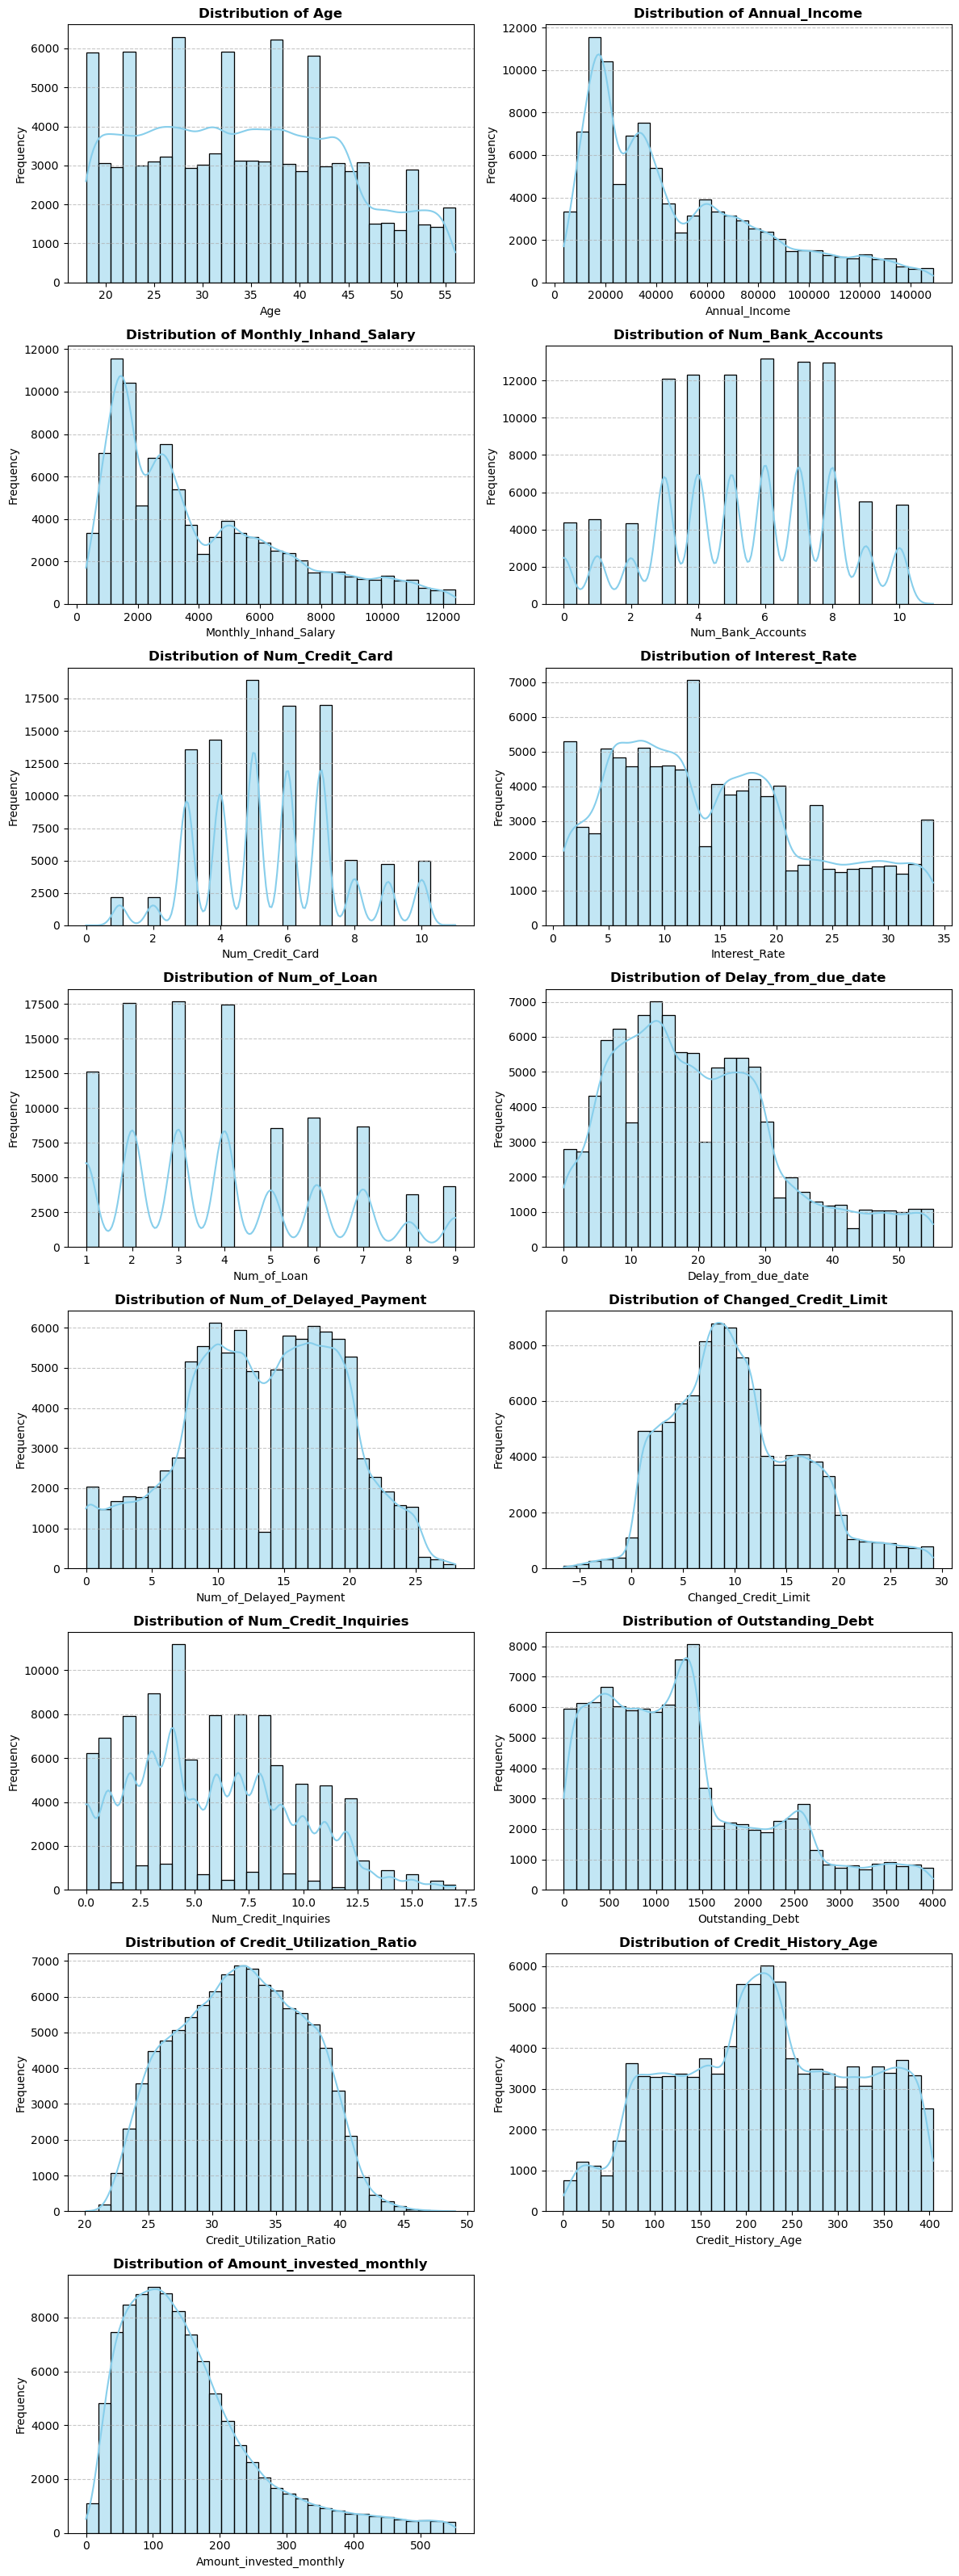

In [67]:
def plot_continuous_distribution(df, continuous_cols, cols_per_row=2):
    num_cols = len(continuous_cols)
    rows = math.ceil(num_cols / cols_per_row)  

    fig, axes = plt.subplots(rows, cols_per_row, figsize=(12, rows * 4))
    axes = axes.flatten()  

    for i, col in enumerate(continuous_cols):
        sns.histplot(df[col].dropna(), kde=True, bins=30, color='skyblue', ax=axes[i])

        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel("Frequency", fontsize=10)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_continuous_distribution(df, continuous_cols)

In [73]:
import pandas as pd
import numpy as np

def drop_multicollinearity(df, threshold=0.9):

    numeric_cols = df.select_dtypes(include=['int64', 'float64'])
    corr_matrix = numeric_cols.corr().abs()
    
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print("Columns to drop due to high correlation:", to_drop)
    df_reduced = df.drop(columns=to_drop)
    return df_reduced
df_reduced = drop_multicollinearity(df, threshold=0.9)

Columns to drop due to high correlation: ['Monthly_Inhand_Salary']


In [74]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_classif, k='all'))
])

pipeline.fit(X, y)

ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(cat_cols)
all_feature_names = list(encoded_cat_features) + num_cols

selector = pipeline.named_steps['selector']
raw_scores = pd.DataFrame({
    'Feature': all_feature_names,
    'F_Score': selector.scores_,
    'P_Value': selector.pvalues_
})

def map_to_original(feature_name):
    for col in cat_cols:
        if feature_name.startswith(col + '_'):
            return col
    return feature_name

raw_scores['Original_Feature'] = raw_scores['Feature'].apply(map_to_original)

aggregated_scores = raw_scores.groupby('Original_Feature').agg({
    'F_Score': 'mean',
    'P_Value': 'min'  # or another strategy
}).reset_index().sort_values(by='F_Score', ascending=False)

print(aggregated_scores)

c:\Users\AFGWO\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


MemoryError: Unable to allocate 30.9 GiB for an array with shape (100000, 41465) and data type float64

We decide to drop Amount_invested_monthly & Credit_Utilization_Ratio as they were 2 least important features, with much lower F1 scores compared to the rest of the features.

### _Addressing Class Imbalance_

In [ ]:
group_counts = df.groupby('Credit_Score').size()
group_counts

Credit_Score
0      352
1    28953
2    52974
3    17721
dtype: int64

Let's deal with the class imbalance before training our model.

We perform **Stratified Sampling** and split our dataset into training and test sets (or into cross-validation folds) such that each split maintains the same class distribution as in the original dataset. If we just randomly split, we could end up with a test set that has very few minority-class examples, or none at all. That would give us an unrealistic sense of our model’s performance. Stratifying ensures each subset is representative of the overall distribution.

Before SMOTE:


C:\Users\irajn\AppData\Local\Temp\ipykernel_25736\2314434721.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=count_data.index, ax=axes[i], palette="viridis")


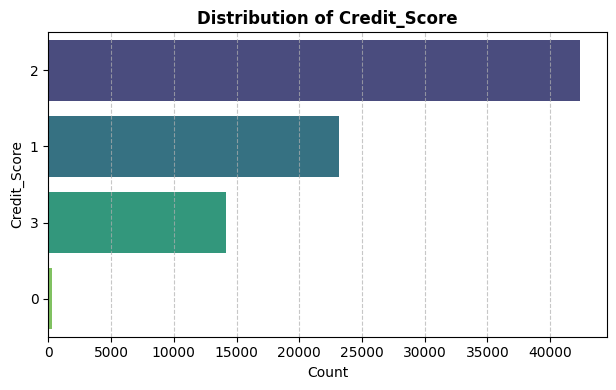

After SMOTE:


C:\Users\irajn\AppData\Local\Temp\ipykernel_25736\2314434721.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=count_data.index, ax=axes[i], palette="viridis")


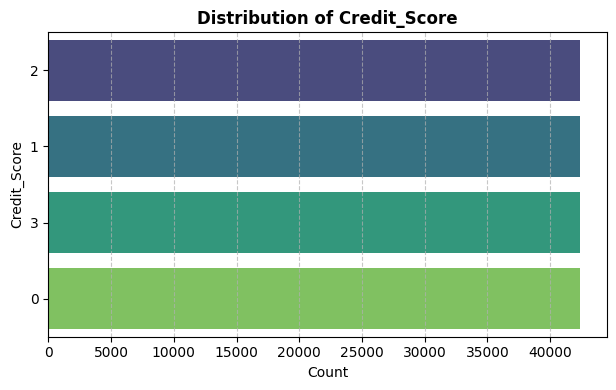

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE


df.drop(['Customer_ID', 'Name', 'Street', 'SSN', 'Monthly_Inhand_Salary', 'Amount_invested_monthly','Credit_Utilization_Ratio', ], axis=1, inplace=True)

df.drop(['Credit_History_Age'], axis=1, inplace=True)

target = 'Credit_Score'
categorical_features = ['Month', 'City', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount']
numeric_features = [col for col in df.columns if col not in categorical_features + [target]]

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='drop'
)


X_train_preprocessed = preprocessor.fit_transform(X_train)

counter_before = pd.Series(y_train).value_counts().sort_index()

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_preprocessed, y_train)

df_before = pd.DataFrame({"Credit_Score": y_train})
df_after  = pd.DataFrame({"Credit_Score": y_train_res})

print("Before SMOTE:")
plot_categorical_distribution(df_before, ['Credit_Score'])

print("After SMOTE:")
plot_categorical_distribution(df_after, ['Credit_Score'])


In [ ]:
# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBClassifier": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42, n_estimators=100)
}

for model_name, model in models.items():
    # Build imblearn pipeline: Preprocess -> SMOTE -> Model
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    
    # Train the pipeline on the training data
    pipeline.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

Model: Logistic Regression
Accuracy: 0.9759
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96        70
           1       0.98      0.97      0.98      5791
           2       0.98      0.98      0.98     10595
           3       0.97      0.97      0.97      3544

    accuracy                           0.98     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000

------------------------------------------------------------
Model: Random Forest
Accuracy: 0.9768
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        70
           1       0.98      0.97      0.98      5791
           2       0.98      0.98      0.98     10595
           3       0.97      0.97      0.97      3544

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20

C:\Users\irajn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [14:03:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: XGBClassifier
Accuracy: 0.9780
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        70
           1       0.98      0.98      0.98      5791
           2       0.98      0.98      0.98     10595
           3       0.97      0.97      0.97      3544

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000

------------------------------------------------------------
Model: GradientBoosting
Accuracy: 0.9762
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        70
           1       0.98      0.97      0.97      5791
           2       0.98      0.98      0.98     10595
           3       0.97      0.97      0.97      3544

    accuracy                           0.98     20000
   macro avg       0.97      0.97      0.97     20000

The accuracy of all our models is around 97% which shows that the data imputation of succesfull. However, this does not guarantee that our model(s) will perform well on real-world, unseen data since we know that our dataset (training set + test set) are tainted with biases.

Let's explore these biases.

### _Addressing Biases_

After looking at the biases, we realised that City is the most important feature which in theory, doesn't make sense. Thus, we explore the bias further.

#### **Bias 1**

In [ ]:
# Count the number of times each Credit_Score appears per City
city_score_counts = df.groupby(['City', 'Credit_Score']).size().unstack(fill_value=0)

# Display the result
print(city_score_counts)


Credit_Score    0      1      2      3
City                                  
BadShire        4  28248    670     67
Lonton          1     53    434  17203
Standhampton    8    652  51865    450
ZeroVille     339      0      5      1


It is very evident that City is a biased column and hence, we drop it.

In [ ]:
df.drop(['City'], axis=1, inplace=True)

#### __Bias 2__

Another bias we found was in Age, where almost every customer with a credit score of 0 had their age exactly equal to 56, which indicates an obvious bias.

In [ ]:
df[df['Credit_Score']==0][["Age", "Credit_Score"]]

,Age,Credit_Score
726,56.0,0
727,56.0,0
3545,56.0,0
3546,56.0,0
3547,56.0,0
...,...,...
98003,56.0,0
98004,56.0,0
98005,56.0,0
98006,56.0,0


Hence, we drop it.

In [ ]:
df.drop(['Age'], axis=1, inplace=True)

#### _Retrain the Model_

In [ ]:
target = 'Credit_Score'
categorical_features = ['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount']
numeric_features = [col for col in df.columns if col not in categorical_features + [target]]

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='drop'
)

X_train_preprocessed = preprocessor.fit_transform(X_train)

counter_before = pd.Series(y_train).value_counts().sort_index()

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_preprocessed, y_train)


missing_numeric = set(numeric_features) - set(X_train.columns)
missing_categorical = set(categorical_features) - set(X_train.columns)
if missing_numeric or missing_categorical:
    print("Missing numeric features:", missing_numeric)
    print("Missing categorical features:", missing_categorical)
    # Adjust your numeric_features and categorical_features accordingly

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='drop'
)

X_train_preprocessed = preprocessor.fit_transform(X_train)

counter_before = pd.Series(y_train).value_counts().sort_index()

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_preprocessed, y_train)  # Rebalancing Credit Score


In [ ]:
for model_name, model in models.items():
    # Build imblearn pipeline: Preprocess -> SMOTE -> Model
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    
    # Train the pipeline on the training data
    pipeline.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

Model: Logistic Regression
Accuracy: 0.7597
Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.79      0.11        70
           1       0.77      0.85      0.81      5791
           2       0.86      0.70      0.77     10595
           3       0.69      0.78      0.73      3544

    accuracy                           0.76     20000
   macro avg       0.59      0.78      0.61     20000
weighted avg       0.80      0.76      0.77     20000

------------------------------------------------------------
Model: Random Forest
Accuracy: 0.8095
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.31      0.44        70
           1       0.79      0.85      0.82      5791
           2       0.83      0.81      0.82     10595
           3       0.78      0.76      0.77      3544

    accuracy                           0.81     20000
   macro avg       0.78      0.68      0.71     20

C:\Users\irajn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [14:33:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: XGBClassifier
Accuracy: 0.7987
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.17      0.28        70
           1       0.78      0.83      0.81      5791
           2       0.81      0.81      0.81     10595
           3       0.79      0.71      0.75      3544

    accuracy                           0.80     20000
   macro avg       0.77      0.63      0.66     20000
weighted avg       0.80      0.80      0.80     20000

------------------------------------------------------------
Model: GradientBoosting
Accuracy: 0.7842
Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.27      0.15        70
           1       0.79      0.79      0.79      5791
           2       0.81      0.80      0.80     10595
           3       0.74      0.74      0.74      3544

    accuracy                           0.78     20000
   macro avg       0.61      0.65      0.62     20000

We notice that as we remove biased columns from the dataset, the performance of all the models decreases significantly, with __Random Forests__ being the best performing model at an 80 % accuracy. 

This is understandable as previously, our training and test set both had biases and suffered as we drop the most 'important' feature (City). Nevertheless, the previous high accuracy of 97% doesn't accurately represent the models' performance on a newer, unbiased dataset and our re-trained models are likely to perform better. 

--------------------------------------------------------------------------------------------------